In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des noms de colonnes pour NSL-KDD
colonnes = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
            'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
            'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 
            'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 
            'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 
            'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'target', 'difficulty_level']

# 2. Chargement des données d'entraînement
df_train = pd.read_csv('../data/KDDTrain+.txt', names=colonnes)

# 3. Afficher les 5 premières lignes pour comprendre à quoi ressemble le réseau
display(df_train.head())

Matplotlib is building the font cache; this may take a moment.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


/tmp/ipykernel_114952/2548874284.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='type_trafic', palette=['#2ecc71', '#e74c3c']) # Vert pour normal, Rouge pour attaque


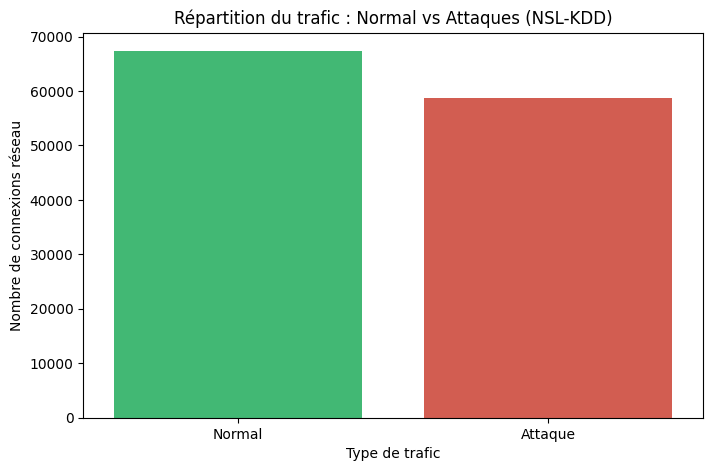

In [2]:
import os

# 1. Créer un dossier "images" s'il n'existe pas déjà
os.makedirs('../images', exist_ok=True)

# 2. Simplifier la cible : 'normal' vs 'attaque' (tout le reste)
df_train['type_trafic'] = df_train['target'].apply(lambda x: 'Normal' if x == 'normal' else 'Attaque')

# 3. Créer le graphique
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='type_trafic', palette=['#2ecc71', '#e74c3c']) # Vert pour normal, Rouge pour attaque
plt.title('Répartition du trafic : Normal vs Attaques (NSL-KDD)')
plt.xlabel('Type de trafic')
plt.ylabel('Nombre de connexions réseau')

# 4. Sauvegarder l'image AUTOMATIQUEMENT pour ton PowerPoint de Vendredi !
plt.savefig('../images/repartition_trafic.png', dpi=300, bbox_inches='tight')

# 5. Afficher le graphique
plt.show()